In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint, uniform
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, classification_report,)
import xgboost as xgb

## Carregamento dos Dados

In [2]:
df_base = pd.read_csv('../Data/fetal_health_base_limpa.csv')

le = LabelEncoder() #pra rodar o XGBoost as classes precisam ser 0,1,2 e elas tavam 1,2,3
y = le.fit_transform(df_base['fetal_health'])
n_classes = len(np.unique(y))

datasets = {
    'Base':          df_base.drop('fetal_health', axis=1),
    'Conservador':   pd.read_csv('../Data/dados_conservador.csv', sep=';'),
    'Intermediário': pd.read_csv('../Data/dados_intermediario.csv', sep=';'),
    'Agressivo':     pd.read_csv('../Data/dados_agressivo.csv', sep=';'),
}

print(f"Classes originais {le.classes_} → codificadas {list(range(n_classes))}")
print(f"Total de amostras : {len(y)}\n")
for name, X in datasets.items():
    print(f"  {name}: {X.shape[1]} features")

Classes originais [1. 2. 3.] → codificadas [0, 1, 2]
Total de amostras : 2126

  Base: 21 features
  Conservador: 19 features
  Intermediário: 17 features
  Agressivo: 14 features


## Divisão Treino / Teste (estratificada)

In [3]:
RANDOM_STATE = 42
TEST_SIZE    = 0.2

splits = {
    name: train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)
    for name, X in datasets.items()
}

for name, (X_train, X_test, y_train, y_test) in splits.items():
    print(f"{name}:treino=1700, teste=426")

Base:treino=1700, teste=426
Conservador:treino=1700, teste=426
Intermediário:treino=1700, teste=426
Agressivo:treino=1700, teste=426


## Funções Auxiliares de Avaliação

In [4]:
def tirar_metricas(model, X_test, y_test, n_classes):
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)
    y_bin   = label_binarize(y_test, classes=list(range(n_classes)))

    return {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'Recall':    recall_score(y_test, y_pred, average='macro', zero_division=0),
        'F1-score':  f1_score(y_test, y_pred, average='macro', zero_division=0),
        'AUC-ROC':   roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro'),
        'AUC-PR':    average_precision_score(y_bin, y_proba, average='macro'),
    }


def treinar_e_avaliar(estimator, param_dist, dataset_name,
                       X_train, X_test, y_train, y_test,
                       n_classes, n_iter=50):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    search = RandomizedSearchCV(
        estimator           = estimator,
        param_distributions = param_dist,
        n_iter              = n_iter,
        cv                  = cv,
        scoring             = 'f1_macro',
        n_jobs              = -1,
        random_state        = RANDOM_STATE,
        refit               = True,
        verbose             = 0,
    )
    search.fit(X_train, y_train)

    best    = search.best_estimator_
    metrics = tirar_metricas(best, X_test, y_test, n_classes)

    print(f"Dataset            : {dataset_name}")
    print(f"CV F1-macro 5-fold : {search.best_score_:.4f}")
    print(f"Melhores parâmetros: {search.best_params_}")
    print("\nClassification Report (conjunto de teste):")
    print(classification_report(y_test, best.predict(X_test), zero_division=0))
    print("Métricas resumidas:")
    for k, v in metrics.items():
        print(f"  {k:12s}: {v:.4f}")

    return best, metrics

## XGBoost — RandomizedSearchCV + StratifiedKFold (5-fold)

In [5]:
xgb_param_dist = {
    'n_estimators':     randint(50, 400),
    'max_depth':        randint(3, 10),
    'learning_rate':    uniform(0.01, 0.29),
    'subsample':        uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 10),
    'gamma':            uniform(0, 0.5),
    'reg_alpha':        uniform(0, 0.5),
    'reg_lambda':       uniform(0.5, 1.5),
}

xgb_results = {}
xgb_models  = {}

for name, (X_train, X_test, y_train, y_test) in splits.items():
    print(f"\n Treinando XGBoost: {name}")
    base_xgb = xgb.XGBClassifier(
        objective    = 'multi:softprob',
        eval_metric  = 'mlogloss',
        random_state = RANDOM_STATE,
        n_jobs       = -1,
    )
    model, metrics = treinar_e_avaliar(
        base_xgb, xgb_param_dist, name,
        X_train, X_test, y_train, y_test, n_classes,
        n_iter=50,
    )
    xgb_results[name] = metrics
    xgb_models[name]  = model


 Treinando XGBoost: Base
Dataset            : Base
CV F1-macro 5-fold : 0.9242
Melhores parâmetros: {'colsample_bytree': np.float64(0.7942455014344907), 'gamma': np.float64(0.22421207149312367), 'learning_rate': np.float64(0.298392664157138), 'max_depth': 6, 'min_child_weight': 1, 'n_estimators': 117, 'reg_alpha': np.float64(0.11862454374840004), 'reg_lambda': np.float64(0.9880995472389016), 'subsample': np.float64(0.8985965620472096)}

Classification Report (conjunto de teste):
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       332
           1       0.87      0.69      0.77        59
           2       0.91      0.91      0.91        35

    accuracy                           0.94       426
   macro avg       0.91      0.86      0.88       426
weighted avg       0.93      0.94      0.93       426

Métricas resumidas:
  Accuracy    : 0.9366
  Precision   : 0.9114
  Recall      : 0.8637
  F1-score    : 0.8841
  AUC-ROC     : 0.9817

## MLP — RandomizedSearchCV + StratifiedKFold (5-fold)

In [6]:
mlp_param_dist = {
    'mlp__hidden_layer_sizes': [
        (64,), (128,), (256,),
        (64, 64), (128, 64), (128, 128),
        (64, 32), (256, 128), (128, 64, 32),
    ],
    'mlp__activation':         ['relu', 'tanh'],
    'mlp__learning_rate_init': uniform(0.0001, 0.0199),
    'mlp__alpha':              [0.0001, 0.001, 0.01, 0.1],
    'mlp__batch_size':         [32, 64, 128],
}

mlp_results = {}
mlp_models  = {}

for name, (X_train, X_test, y_train, y_test) in splits.items():
    print(f"\nTreinando MLP:  {name}")
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPClassifier(
            max_iter         = 1000,
            early_stopping   = True,
            n_iter_no_change = 20,
            random_state     = RANDOM_STATE,
        )),
    ])
    model, metrics = treinar_e_avaliar(
        pipeline, mlp_param_dist, name,
        X_train, X_test, y_train, y_test, n_classes,
        n_iter=30,
    )
    mlp_results[name] = metrics
    mlp_models[name]  = model


Treinando MLP:  Base
Dataset            : Base
CV F1-macro 5-fold : 0.8583
Melhores parâmetros: {'mlp__activation': 'tanh', 'mlp__alpha': 0.0001, 'mlp__batch_size': 64, 'mlp__hidden_layer_sizes': (64, 64), 'mlp__learning_rate_init': np.float64(0.004896406773917634)}

Classification Report (conjunto de teste):
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       332
           1       0.70      0.47      0.57        59
           2       0.84      0.74      0.79        35

    accuracy                           0.88       426
   macro avg       0.82      0.73      0.76       426
weighted avg       0.87      0.88      0.88       426

Métricas resumidas:
  Accuracy    : 0.8850
  Precision   : 0.8162
  Recall      : 0.7301
  F1-score    : 0.7646
  AUC-ROC     : 0.9595
  AUC-PR      : 0.8341

Treinando MLP:  Conservador
Dataset            : Conservador
CV F1-macro 5-fold : 0.8490
Melhores parâmetros: {'mlp__activation': 'tanh', 'mlp__alph

## Comparação de Resultados — XGBoost vs MLP

Accuracy  Precision  Recall  F1-score  AUC-ROC  AUC-PR
Dataset       Modelo                                                         
Base          XGBoost    0.9366     0.9114  0.8637    0.8841   0.9817  0.9299
              MLP        0.8850     0.8162  0.7301    0.7646   0.9595  0.8341
Conservador   XGBoost    0.9437     0.9100  0.8853    0.8961   0.9818  0.9284
              MLP        0.8897     0.7996  0.7654    0.7815   0.9697  0.8541
Intermediário XGBoost    0.9390     0.9065  0.8740    0.8878   0.9813  0.9280
              MLP        0.8803     0.7905  0.7397    0.7620   0.9582  0.8441
Agressivo     XGBoost    0.9413     0.9194  0.8665    0.8899   0.9799  0.9270
              MLP        0.8967     0.8136  0.8164    0.8150   0.9593  0.8567

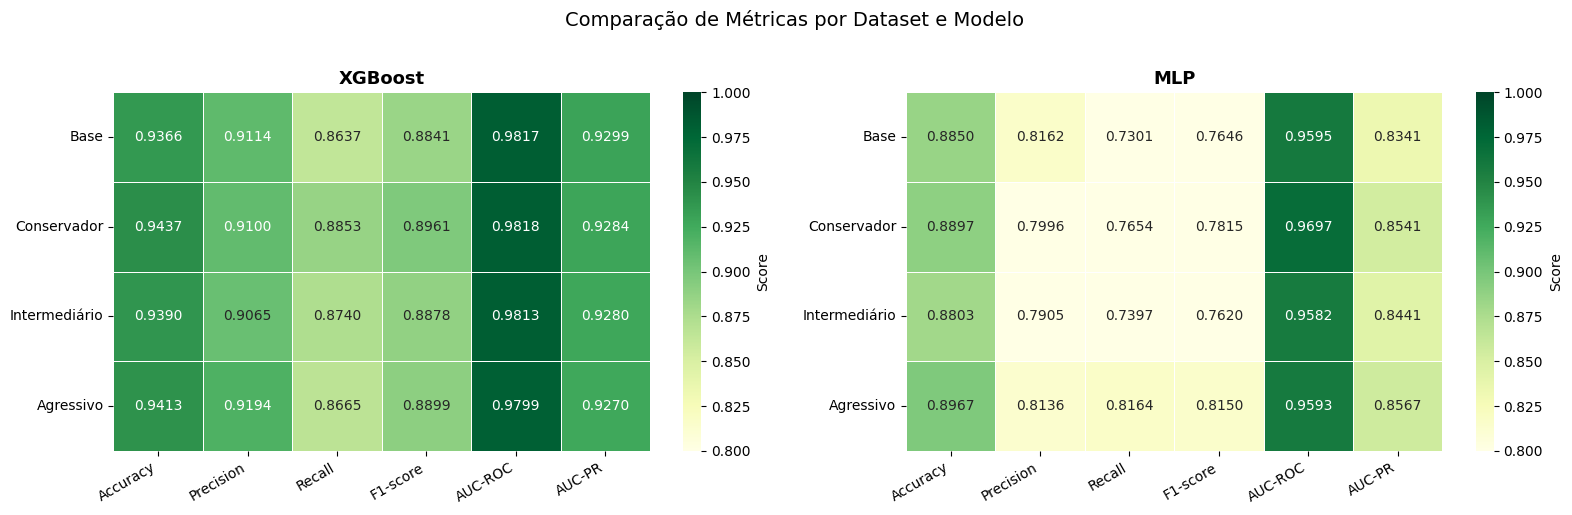

In [10]:
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC-ROC', 'AUC-PR']
dataset_names = list(datasets.keys())

rows = []
for name in dataset_names:
    rows.append({'Dataset': name, 'Modelo': 'XGBoost', **xgb_results[name]})
    rows.append({'Dataset': name, 'Modelo': 'MLP',     **mlp_results[name]})

df_results = (
    pd.DataFrame(rows)
    .set_index(['Dataset', 'Modelo'])
    .round(4)
)
display(df_results)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (model_name, model_results) in zip(axes, [('XGBoost', xgb_results), ('MLP', mlp_results)]):
    data = pd.DataFrame(model_results, index=metric_cols).T
    sns.heatmap(data, annot=True, fmt='.4f', cmap='YlGn', vmin=0.8, vmax=1.0,
                ax=ax, linewidths=0.5, cbar_kws={'label': 'Score'})
    ax.set_title(model_name, fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    ax.set_yticklabels(dataset_names, rotation=0)

plt.suptitle('Comparação de Métricas por Dataset e Modelo', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../Figures/heatmap_comparacao.png', dpi=150, bbox_inches='tight')
plt.show()

### O melhor desempenho foi o do XGBOOST no geral
### No XGBOOST o melhor dataset foi o conservador (tiramos duas features que davam ruído), entretando no dataset que tinhamos apenas 14 features (agressivo) ele performou de forma muito semelhante e satisfatória em todas as métricas. Assim, o selecionamos por ser um modelo mais simples (menor custo computacional) com uma maior generalização 

### No caso das MLP´S o desempenho foi substancialmente inferior, mas não necessáriamente ruim
### E o melhor dos casos foi no Dataser "agressivo" com 14 features (não tem uma diferença tão grande, mas teve o melhor desempenho com o menor custo computacional), tendo em vista que algumas features geravam ruídos pros pesos da rede.

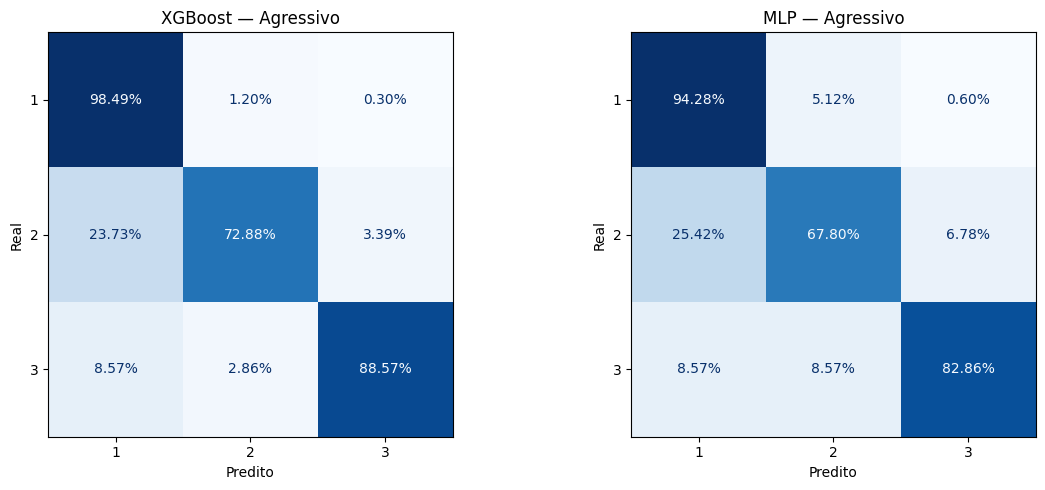

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

dataset_name = 'Agressivo'
_, X_test_ag, _, y_test_ag = splits[dataset_name]
class_labels = [str(c) for c in le.classes_.astype(int)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (model_name, model) in zip(axes, [('XGBoost', xgb_models[dataset_name]),
                                           ('MLP',     mlp_models[dataset_name])]):
    cm = confusion_matrix(y_test_ag, model.predict(X_test_ag), normalize='true')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='.2%')
    ax.set_title(f'{model_name} — {dataset_name}', fontsize=12)
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.savefig('../Figures/matriz_confusao_agressivo.png', dpi=150, bbox_inches='tight')
plt.show()

### Há uma certa confusão entre as classes de um feto saudável e suspeito, tendo em vista que um feto suspeito ainda sim pode ser um feto saudável. Por isso em alguns casos os fetos que são verdadeiramente saudáveis são classificados como suspeito

### Desta forma a classificação mais importante é classificar corretamente um feto patológico, prinicipalmente no caso de predizer saudável e ser realmente da classe patológico